Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Spatial dependence

## An introduction to connectivity in PySAL

In this chapter / notebook we will look at the foundational idea of spatial statistics,
Tobler's first law of geography:

> everything is related to everything else, but near things are more related
than distant things

From a practical sense this means to perform spatial analysis you must have a
measure to link data by its location, i.e. how far apart is the data?

PySAL, the Python Spatial Analysis Library is a library built to perform
calculations of spatial statistics in Python. In this notebook you'll use the
PySAL `weights` module to link the suburbs of the ACT to answer the question
"where is your closest hospital?".

To do this start by reading the data. At the same time you'll join on the 2016
population of the ACT to show a little more context in the data for when you
perform your analysis:

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 12)

import geopandas as gpd
import pandas as pd

# original source: https://www.data.act.gov.au/api/views/j2uh-gmak/rows.csv?accessType=DOWNLOAD
population = pd.read_csv("Data/spatial/ACT/act_population_2016.csv", index_col="Code")
population.head()

,Females,Males,Persons
Code,,,
80101,43970,43357,87327
80103,457,681,1138
80104,16682,16068,32750
80105,21720,22111,43831
80106,12137,11655,23792


In [4]:
sa2_boundaries = gpd.read_file("Data/spatial/ACT/SA2_2016_AUST.shp")
# set the index so it matches the SA2 code from the population dataset
sa2_boundaries['SA2_5DIG16'] = sa2_boundaries['SA2_5DIG16'].astype(int)
sa2_boundaries.set_index('SA2_5DIG16', inplace=True)
sa2_boundaries.head()  # notice, this is a national dataset!

,SA2_MAIN16,SA2_NAME16,SA3_CODE16,SA3_NAME16,SA4_CODE16,SA4_NAME16,GCC_CODE16,GCC_NAME16,STE_CODE16,STE_NAME16,AREASQKM16,geometry
SA2_5DIG16,,,,,,,,,,,,
11007,101021007,Braidwood,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,3418.3525,"POLYGON ((149.58423 -35.44427, 149.58444 -35.4..."
11008,101021008,Karabar,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,6.9825,"POLYGON ((149.21898 -35.36739, 149.21799 -35.3..."
11009,101021009,Queanbeyan,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,4.7634,"POLYGON ((149.21325 -35.34325, 149.21619 -35.3..."
11010,101021010,Queanbeyan - East,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,13.0034,"POLYGON ((149.24033 -35.34782, 149.24023 -35.3..."
11011,101021011,Queanbeyan Region,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,3054.4099,"POLYGON ((149.23580 -35.38738, 149.23771 -35.3..."


In [6]:
# the inner join limits the data to just ACT, the reset_index and projections are helpers for PySAL
act_sa2_boundaries = sa2_boundaries.join(population, how="inner").reset_index().to_crs(epsg=7855)

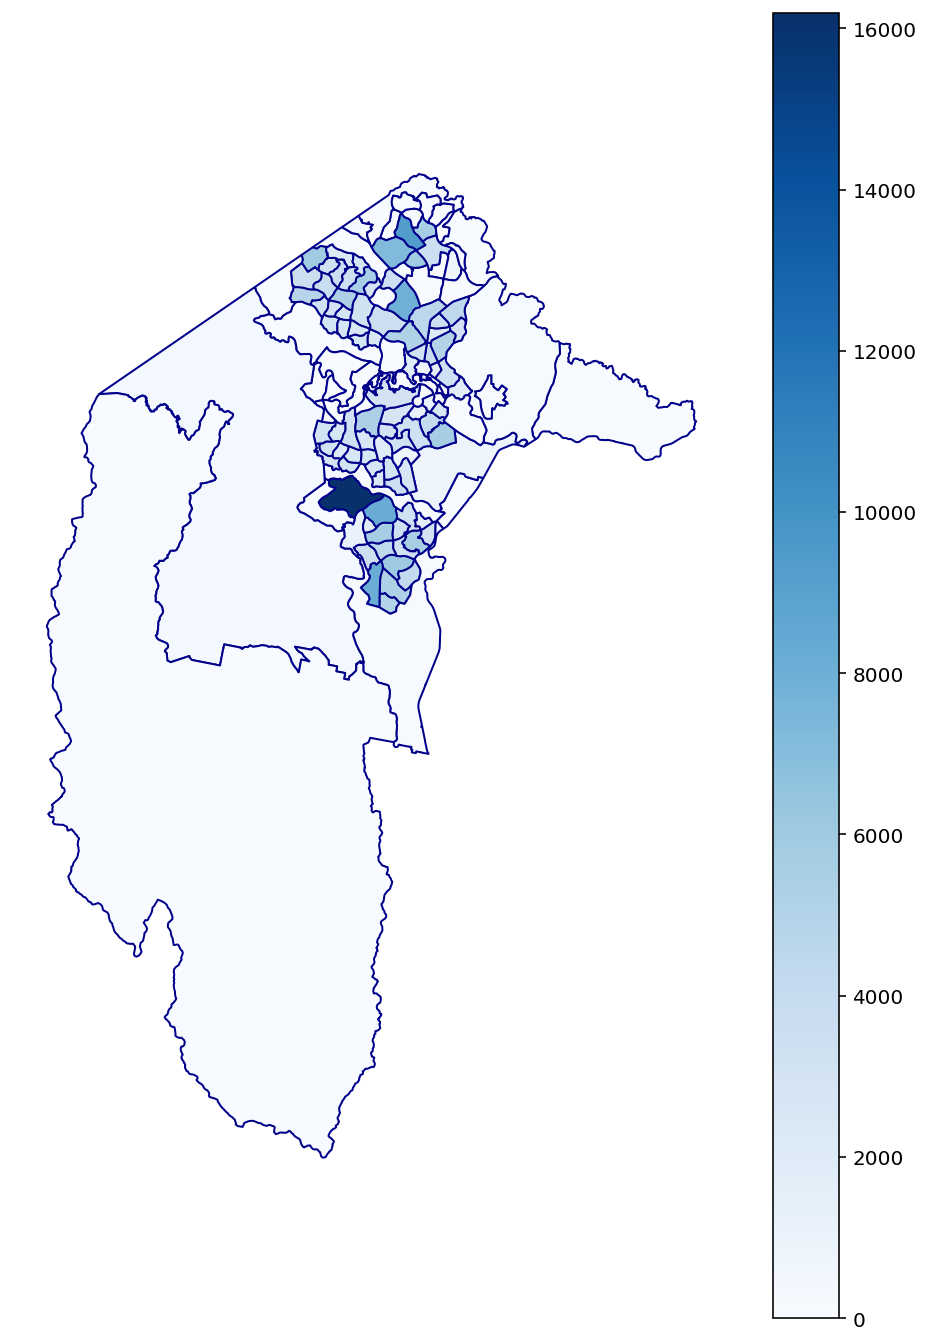

In [7]:
ax = act_sa2_boundaries.plot(column="Persons", legend=True, cmap="Blues", edgecolor='darkblue')
ax.set_axis_off()

Visually you can see some SA2 areas are closer together than others. However you
must be able to model this to perform analysis. PySAL does this through the
`weights` module allowing the creation of spatial weights objects - effectively
the linkage between your spatial data. For example:

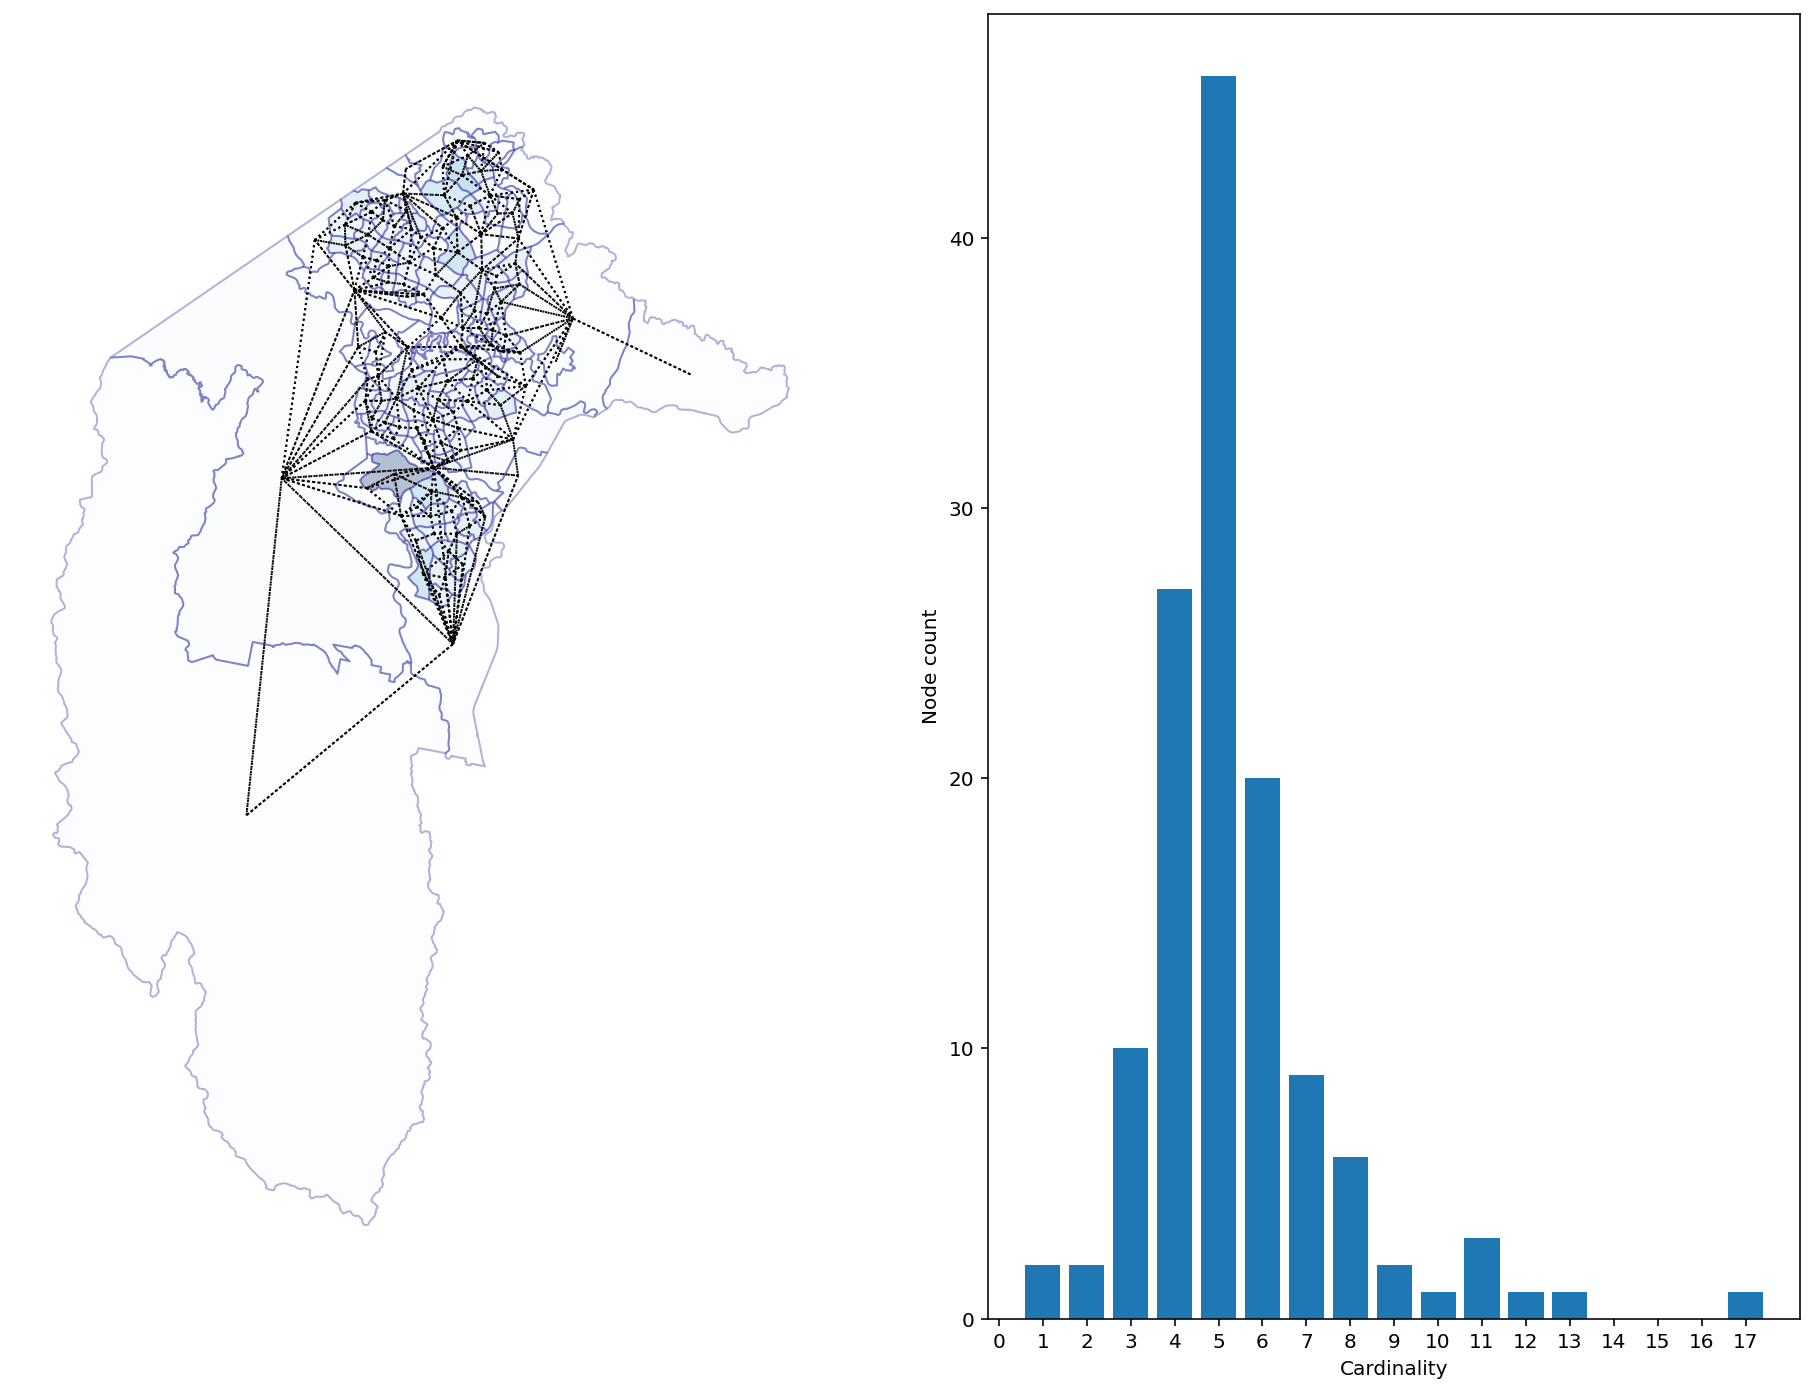

In [8]:
from libpysal import weights

w_rook = weights.Rook.from_dataframe(act_sa2_boundaries)

def nicely_plot_act_weights(w):
    fig, axes = plt.subplots(ncols=2, figsize=(16, 12))
    act_sa2_boundaries.plot(column="Persons", cmap="Blues", edgecolor='darkblue', alpha=0.3, ax=axes[0])
    w.plot(act_sa2_boundaries, ax=axes[0], edge_kws={"linestyle": ":", "linewidth": 1}, node_kws={"marker": ""})
    axes[0].set_axis_off()
    axes[1].bar(*zip(*w.histogram))
    axes[1].set_xlabel("Cardinality")
    axes[1].set_xticks(range(max(w.cardinalities.values()) + 1))
    axes[1].set_ylabel("Node count");

nicely_plot_act_weights(w_rook)

As you can see this connects together adjacent polygon boundaries. The `Rook`
connectivity requires that two objects share an edge to be adjacent. `Queen` on
the other hand requires that two objects merely share a single vertex. The
easiest way to mentally visualize this, and the origin of these names comes from
the layout of squares on a chessboard; the Rook can only move up, down, left and
right, but the Queen can move on any diagonal.

### Quick exercise

Create a `Queen` weights object and plot it in the same method as above.

In [12]:
#%load solutions/queen_connectivity.py

Depending on the type of data you have there are a number of different weight
calculation methods that are applicable. If you tried to use the `Rook` on a
point dataset your weights would be empty. So it's important to make the
distinction when looking at what linkage method to use. Some of the most common
are given below (note: these are incomplete):

#### Contiguity based weights

- `Rook` and `Queen` on datasets as above where you have a continuous set of
polygons
- `Voronoi` which allows calculating `Rook` or `Queen` based weights based on
the Voronoi tesselation of a points dataset

#### Distance based weights

- `KNN` links the *k* nearest neighbours in point datasets
- `DistanceBand` thresholds connectivity to a given distance

#### Raster weights

- `lat2W` creates a rook or a queen weights set for a regular lattice

### Exercise: Creating `DistanceBand` weights for the centroids of the SA2 areas

1. Create a GeoDataFrame that contains the centroid of each of the SA2
boundaries as above: `act_sa2_boundaries.centroid.to_frame("geometry")`
2. Create a DistanceBand weight object with a threshold of 3km (`3000` metres)
3. Use the `weights.w_difference` method to plot the edges in the Rook weights
set that are not in the distance threshold weight set. *Hint* use the
`constrained=True` keyword argument to get back the difference rather than all
nodes.

Notice that you are warned about disconnected components and islands. The
disconnected components are the number of discrete subgraphs in the graph made
up from the linkage. Islands are nodes in the graph (centroids in this case)
which are not linked to any other nodes. In general you have two choices: drop
the disconnected islands from your analysis; or connect the islands to the
remainder of the graph using a different linkage method.

4. Create a new `KNN` weights object, where `k=1` (to connect every node to its
one nearest neighbour).
5. Use the `weights.attach_islands` method to update the distance weights object
to connect the nearest neighbour and plot the results.

In [13]:
# %load solutions/distance_band.py

## Spatial lag

One method to measure spatial dependence is to model the autocorrelation
directly, as would be done with autocorrelated time-series data. One such model
is the spatial lag model, in which a dependent variable is predicted using the
value of the dependent variable of an observation's neighbours in the weight
graph.

$$
Y_i = \rho WY_j + \beta X_i + \epsilon_i
$$

Where $Y_j$ is the set of $Y$ values from observations other than $i$, $W$ is a matrix of spatial weights which are higher for $j$s that
are spatially closer to $i$, and $\rho$ and $\beta$ are coefficients estimated using separate
processes.

We will look at measures of spatial autocorrelation later in the session. For
now we will simply calculate the spatial lag and compare these values the
original.

In [14]:
act_sa2_boundaries["weighted_persons"] = weights.lag_spatial(w_rook, act_sa2_boundaries["Persons"])

Since the weights object has not been row standardized the above value is the
weighted sum of each observation's neighbours.

<AxesSubplot:xlabel='Persons', ylabel='weighted_persons'>

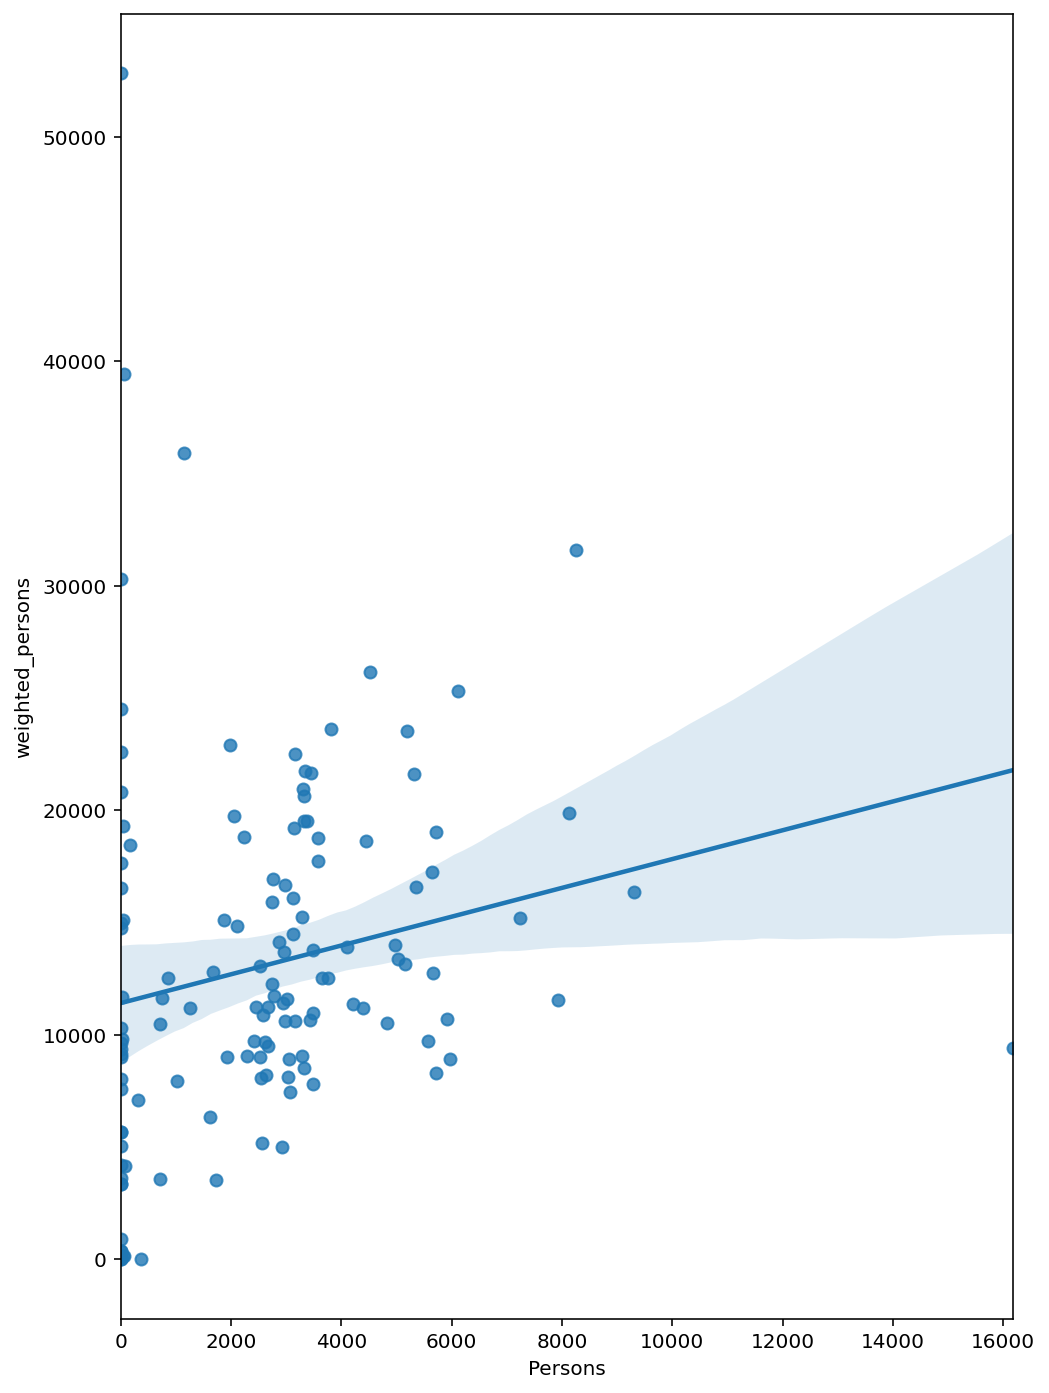

In [15]:
import seaborn as sns
sns.regplot(x="Persons", y="weighted_persons", data=act_sa2_boundaries)

Note this method of estimating values is *extremely* dependent on the way the
weights object is defined.

### Exercise: Calculating the distance band on kernel weightings

Create a new `Kernel` based weighting for the suburb centroids. This will
generate many more linkages in the data if you were to plot it out, but
importantly the linkages are weighted differently depending on the distance.

1. Compare the `w_rook.weights` attribute to the `weights` attribute of the
kernel weights.
2. Use the kernel weights to calculate the spatial lag (as above) and plot the
results.

Is this a good estimation of population in the ACT?

In [16]:
# %load solutions/kernel_weights.py

## Spatial autocorrelation

Autocorrelation is the similarity of objects with a lag between them. For
standard time-series autocorrelation this is the similarity of objects with some
lag in time (what happens today is dependent on something that happens last
week). For spatial autocorrelation which you'll see here it is the dependence of
an object on the location of itself in comparison to its neighbours. To measure
spatial autocorrelation in Python the best library to use is the Python Spatial
Analysis Library, PySAL.

First you'll need some some data, and along side the data you'll need to
calculate the spatial weights:

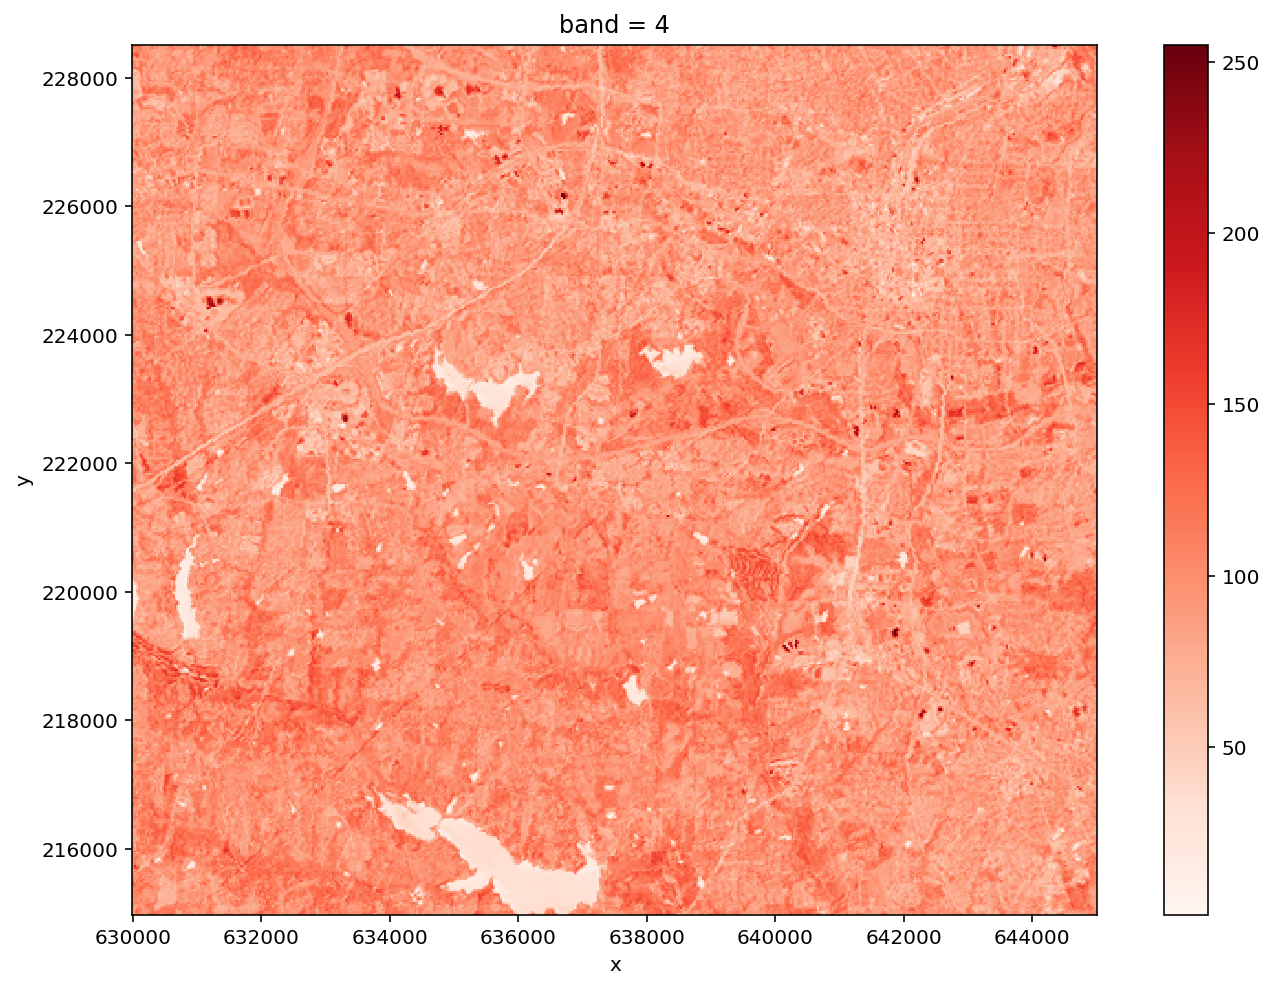

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 8)

import xarray as xr
from libpysal import weights

landsat = xr.open_rasterio("Data/spatial/lsat7_2002/lsat.vrt")

ax = landsat.sel(band=4).plot(cmap="Reds")
ax.axes.set_aspect('equal')

In modern PySAL there are shortcuts to produce weights objects directly from the
data array. The result is effectively the same as the `weights.lat2W` method
with enhancements that you can include a third dimension (e.g. time or bands)
and you can automatically drop null data from connectivity.

In [5]:
w_lattice = weights.da2W(landsat, criterion='rook')

At this point you can use the sparse weights in place of a standard weights
object. For example it can be used to calculate measures of spatial dependence,
i.e. spatial autocorrelation. The first of these to be calculated will be
Moran's I. This we will first calculate as a global measure:

In [6]:
from esda import Moran

moran = Moran(landsat.sel(band=4).values, w_lattice)

Moran's I is measured on a scale of -1 to 1, with -1 being perfectly negatively
correlated, 0 being no correlation, and 1 being perfectly positively correlated.
We can examine the value of I and comparative statistics from the Moran object:

In [8]:
moran.I

0.756688651452165

In [9]:
moran.EI

-3.994822709768141e-06

In [10]:
moran.p_norm

0.0

In [11]:
moran.p_sim

0.001

The `moran.I` shows you the I score of the dataset. `moran.EI` is the expected
value of I under the normality assumption, `moran.p_norm` is the p-value under
the normality assumption, and `moran.p_sim` is a simulation of how likely the
result is under a random process. The `moran.p_sim` is the typically the value
we talk about as the P value of a spatial autocorrelation method. A low-enough
p-value allows us to reject the hypothesis that the map is random. These values
show use this dataset is highly spatially autocorrelated, i.e. exhibits a high
degree of spatial dependence.

By comparison if you generate random data and process it with the same weights
objects:

In [12]:
import numpy as np

moran_random = Moran(np.random.random(landsat.sel(band=4).shape), w_lattice)
moran_random.I

-0.0021474893502005025

In [15]:
moran_random.EI

-3.994822709768141e-06

In [16]:
moran_random.p_norm

0.12983880796959432

A helpful method to understand the shape of autocorrelation of the data is the
Moran plot. Here you see a plot of actual vs spatially lagged values divided
into four quadrants:

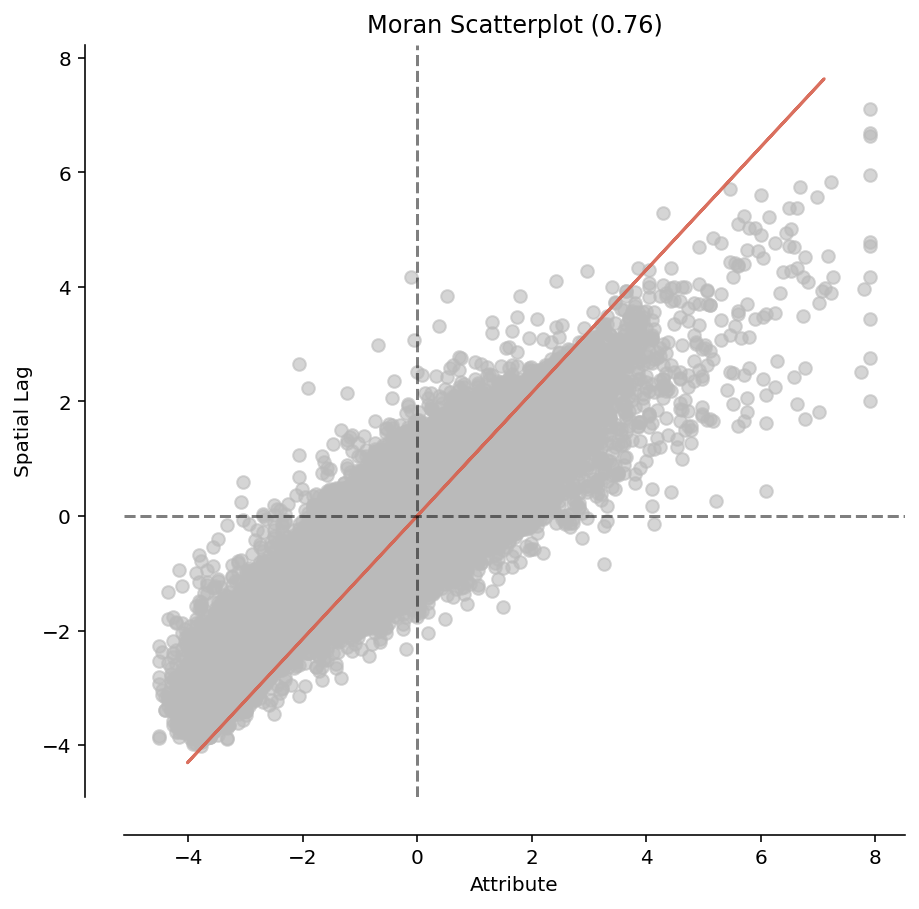

In [17]:
from splot.esda import moran_scatterplot

moran_scatterplot(moran, aspect_equal=True);

The four quadrants can be thought of as:

- The top-left is known as the Low-High (LH) quadrant. It represents data where
the actual values are lower than you might expect from the surroundings. If this
location has significant local autocorrelation it is known as a "doughnut" (from
the hole).
- The bottom-right is known as the High-Low (HL) quadrant. It represents data
where the actual values are higher than expected given the surrounding values.
If this location has significant local autocorrelation it is known as a
"diamond" (from diamond in the rough).
- The top-right is known as the High-High (HH) quadrant. Areas of significant
local autocorrelation for HH values are hotspots in a dataset.
- Finally, the bottom-left is known as the Low-Low (LL) quadrant. Areas of
significant local autocorrelation for LL values are coldspots in the dataset.

### Exercise: Measuring autocorrelation with Geary's C

Another measure of autocorrelation is Geary's C. Use the `esda.Geary` to measure
the autocorrelation of this red band of data. What is the value of the `C`
attribute? Note that the C value is bounded by 0 (perfect autocorrelation) to
infinity (perfect negative autocorrelation). The values relate heavily to
Moran's I, but are calculated in a different method and don't always correspond.
Finally, is this significant under the random assumption? i.e. what is the
`p_sim` value?

In [19]:
# %load solutions/geary.py

## Local indicators of spatial autocorrelation (LISA)

So how to measure local autocorrelation? Happily most global autocorrelation
measures like Moran's I and Geary's C have local spatial autocorrelation
equivalents which you can calculate with the same parameters as the global
equivalents. However this is a memory intensive operation so in this case you
can use a smaller dataset to demonstrate its use:

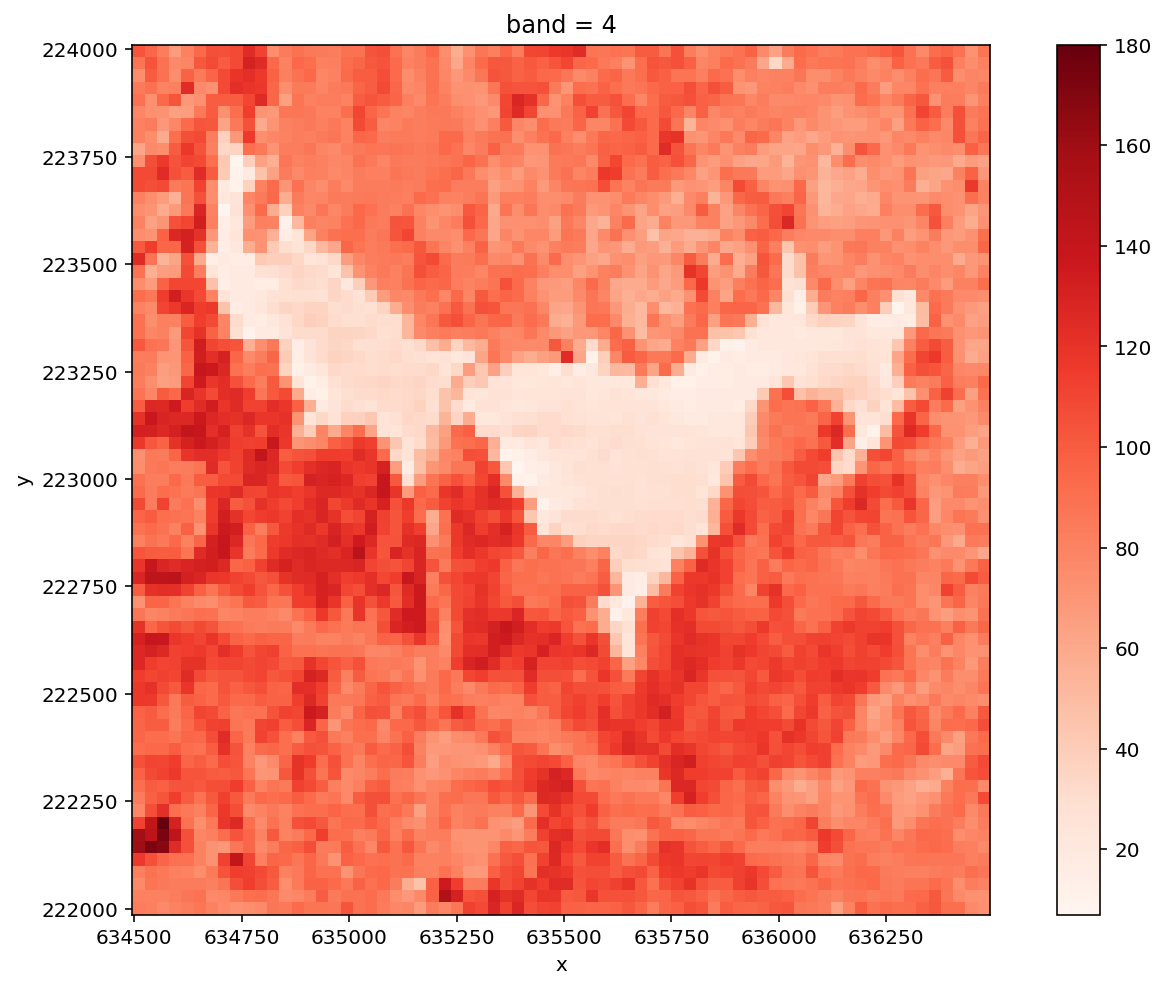

In [20]:
lake = landsat.loc[4, 224000:222000, 634500:636500]
ax = lake.plot(cmap="Reds")
ax.axes.set_aspect('equal')

In [21]:
small_w_lattice = weights.da2W(lake)  # in general you should use a sparse matrix representation of a weights object instead - weights.da2WSP

In [22]:
from esda import Moran_Local

**Note:** this can take a while to run particularly with raster datasets. Consider getting coffee!

In [23]:
%time moran_local = Moran_Local(lake.values, small_w_lattice)

CPU times: user 3.9 s, sys: 31.5 ms, total: 3.93 s
Wall time: 3.93 s


Once you have the `moran_local` object calculated you can start to look at
significant values. The first, most obvious to look at is whether the I values:

In [24]:
moran_local.Is

array([ 0.29265824,  0.13905779, -0.00233414, ..., -0.02663113,
        0.06286169,  0.13509656])

Unfortunately on a local scale these are not particularly meaningful. It might
be better to plot individual values instead

(<Figure size 504x504 with 1 Axes>,
 <AxesSubplot:title={'center':'Moran Local Scatterplot'}, xlabel='Attribute', ylabel='Spatial Lag'>)

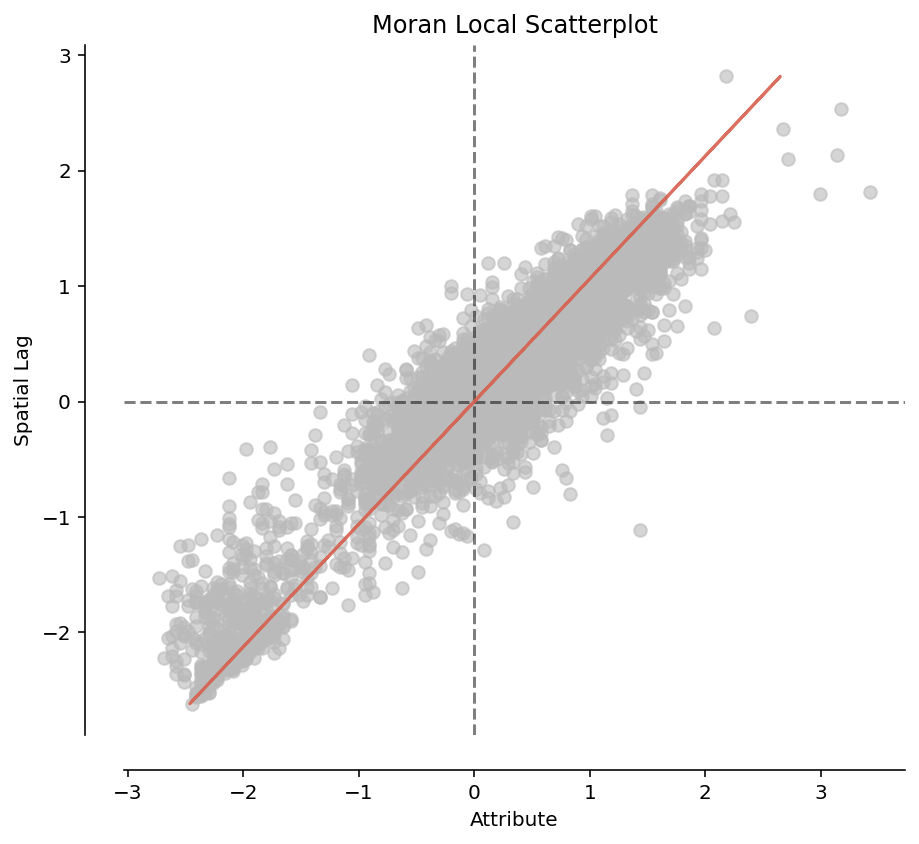

In [25]:
moran_scatterplot(moran_local)

Still by itself this isn't particularly useful. However like our global Moran's
I we have an estimated P value under the randomization assumption, but instead
of for a single value we have one for every value in the dataset:

In [26]:
moran_local.p_sim

array([0.227, 0.22 , 0.407, ..., 0.425, 0.319, 0.264])

If we treat the threshold for significance as the standard 0.05, it's very easy
to find locally significant values:

In [27]:
significant = (moran_local.p_sim < 0.05).reshape(lake.shape)

And of course we can plot out this binary array:

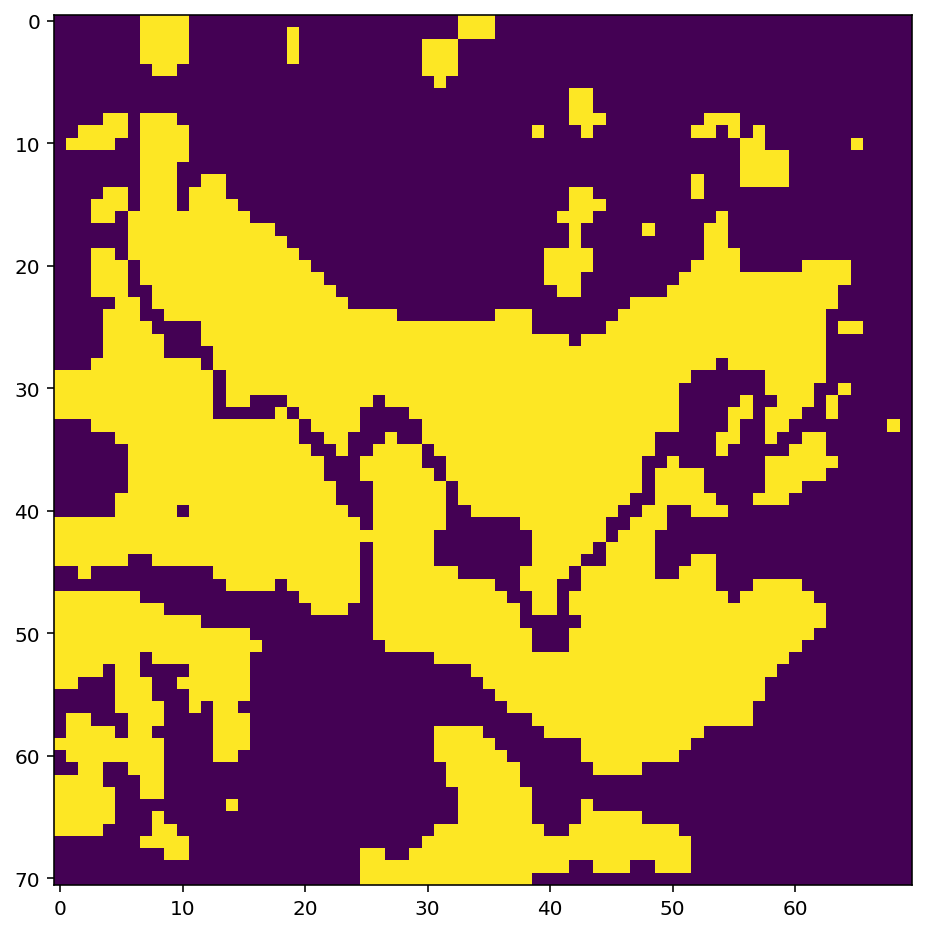

In [28]:
import matplotlib.pyplot as plt

ax = plt.imshow(significant)
ax.axes.set_aspect('equal')

Here under our current assumptions much of the data is significant. But we can
go further by looking at the `q` attribute - the quadrant, where

1. is HH,
2. is LH,
3. is LL, and
4. is HL

In [30]:
moran_local.q

array([1, 1, 2, ..., 4, 3, 3])

If you remember the definitions from our graph earlier a doughnut (a low value
surrounded by high values) was a significant value in the LH quadrant. With
simple NumPy boolean algebra this is easy to determine:

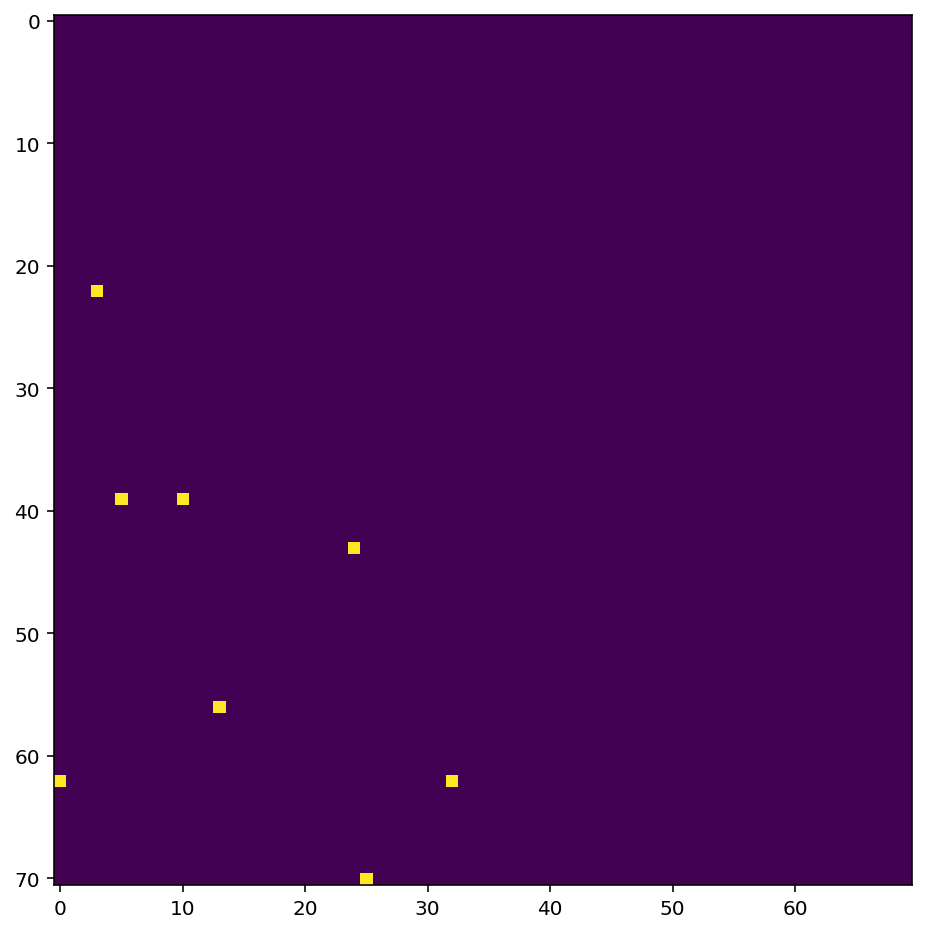

In [31]:
lh = (moran_local.q == 2).reshape(lake.shape)
doughnut = lh & significant
plt.imshow(doughnut)

### Exercise: Find diamonds in the rough

1. Use the quadrants and the significant values to find diamonds (HL) and plot
the result
2. Use the quadrants and significant values to find overall coldspots in the
data (LL) and plot the result
3. Compare the plot of the coldspots to the original data - what do you think
the data is showing you?

In [34]:
# %load solutions/diamonds.py

## Further resources

If you want more in depth resources on spatial weighs, autocorrelation,
regression and interpolation see the online book *Geographic Data Science with PySAL
and the PyData Stack* by Sergio K Rey, Dani Arribas-Bel, and Lev J Wolf:
[here](https://geographicdata.science/book/intro.html).